# Diputrax

Analisis de patrones de reclutamiento para comites legislativos de la camra de diputados del Congreso de la Union de los Estados Unidos Mexicanos.

# 1. Resumen ejecutivo

resumen

## 1.1 Contexto y definicion del area de interes

Contexto


Area de interes
Patrones de reclutamiento de comisiones

## 1.2 Objetivos y criterios de exito

Objetivo primario
d

Objetivos secundarios
d

Directivas de la evaluacion de modelos
d

## 1.3 Datos

kjkjkkk

## 1.4 Criterios de interpretabilidad del modelo


Se considera que 

## 1.5 Alcance del proyecto

dfdfdf

## 1.6 Fuera de alcance del proyecto

sadadasdasdasd

# 2. Estrategia metodológica

In [1]:
# =========================
# Importación de dependencias y carga de datos
# =========================

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display, HTML

sns.set_theme(style="whitegrid", context="talk", palette="deep")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.frameon"] = False
pd.set_option("display.max_columns", 100)

DATA_PATH = Path("/home/miso/Projects/diputrax/data/database/clean/diputados_20260421_205712.parquet")
REPORT_PATH = Path("/home/miso/Projects/diputrax/reports/eda/sqleda_20260421_205712.md")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"No existe archivo parquet: {DATA_PATH}")
if not REPORT_PATH.exists():
    raise FileNotFoundError(f"No existe reporte base: {REPORT_PATH}")

df = pd.read_parquet(DATA_PATH).copy()
print(f"Fuente de datos: {DATA_PATH}")
print(f"Reporte base: {REPORT_PATH}")
print(f"Dimensión: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")

roman_map = {
    57: "LVII", 58: "LVIII", 59: "LIX", 60: "LX", 61: "LXI",
    62: "LXII", 63: "LXIII", 64: "LXIV", 65: "LXV", 66: "LXVI",
}

era_map = {
    57: "ERA_1", 58: "ERA_1", 59: "ERA_1",
    60: "ERA_2", 61: "ERA_2", 62: "ERA_2",
    63: "ERA_3", 64: "ERA_3", 65: "ERA_3",
    66: "ERA_4",
}

era_label_map = {
    "ERA_1": "ERA_1 - LVII-LIX",
    "ERA_2": "ERA_2 - LX-LXII",
    "ERA_3": "ERA_3 - LXIII-LXV",
    "ERA_4": "ERA_4 - LXVI",
}

era_nombre_map = {
    "ERA_1 - LVII-LIX": "Primera época",
    "ERA_2 - LX-LXII": "Segunda época",
    "ERA_3 - LXIII-LXV": "Tercera época",
    "ERA_4 - LXVI": "Cuarta época",
}

era_order = ["ERA_1", "ERA_2", "ERA_3", "ERA_4"]
era_nombre_order = ["Primera época", "Segunda época", "Tercera época", "Cuarta época"]

plot_df = df.copy()
plot_df["legislatura_roman"] = plot_df["legislatura_num"].map(roman_map)
plot_df["era"] = plot_df["legislatura_num"].map(era_map)
plot_df["era_label"] = plot_df["era"].map(era_label_map).map(era_nombre_map)

if plot_df["era"].isna().any():
    missing_legs = sorted(plot_df.loc[plot_df["era"].isna(), "legislatura_num"].dropna().unique().tolist())
    raise ValueError(f"Legislaturas sin era asignada: {missing_legs}")

plot_df["era"] = pd.Categorical(plot_df["era"], categories=era_order, ordered=True)
plot_df["era_label"] = pd.Categorical(plot_df["era_label"], categories=era_nombre_order, ordered=True)

plot_df[["legislatura_num", "legislatura_roman", "era", "era_label"]].drop_duplicates().sort_values("legislatura_num")

resumen_era = (
    plot_df.groupby("era_label")
    .agg(
        filas=("diputado_id", "size"),
        legislaturas=("legislatura_num", lambda s: ", ".join(sorted({roman_map[x] for x in s}))),
        diputados_unicos=("diputado_id", "nunique"),
        edad_promedio=("edad_al_tomar_cargo", "mean"),
        comisiones_promedio=("n_comisiones", "mean"),
        nodales_promedio=("n_comisiones_nodales", "mean"),
        tematicas_promedio=("n_comisiones_tematicas", "mean"),
        lastre_promedio=("n_comisiones_lastre", "mean"),
    )
    .reset_index()
)

display(resumen_era.round(2))

Fuente de datos: /home/miso/Projects/diputrax/data/database/clean/diputados_20260421_205712.parquet
Reporte base: /home/miso/Projects/diputrax/reports/eda/sqleda_20260421_205712.md
Dimensión: 5,000 filas x 78 columnas


,era_label,filas,legislaturas,diputados_unicos,edad_promedio,comisiones_promedio,nodales_promedio,tematicas_promedio,lastre_promedio
0,Primera época,1500,"LIX, LVII, LVIII",1468,44.82,3.57,0.47,1.53,0.51
1,Segunda época,1500,"LX, LXI, LXII",1476,45.76,4.40,0.63,1.93,0.58
2,Tercera época,1500,"LXIII, LXIV, LXV",1371,47.37,4.19,0.82,2.15,0.68
3,Cuarta época,500,LXVI,500,48.37,3.23,0.88,1.87,0.45


dfdfd

dfdf


In [2]:
# ============================================================
# METADATOS DE COLUMNAS
# ============================================================
# Este diccionario define, para cada columna del DataFrame,
# dos cosas:
# 1) el grupo temático al que pertenece
# 2) una descripción breve de su significado
#
# La estructura es:
# "nombre_columna": ("Grupo temático", "Descripción")
COLUMN_META = {
    # ── Identificadores ──────────────────────────────────────
    "diputado_id":               ("Identificadores", "Hash único del diputado"),
    "referencia":                ("Identificadores", "ID numérico en la fuente original"),
    "nombre":                    ("Identificadores", "Nombre completo del diputado"),
    "legislatura_nombre":        ("Identificadores", "Nombre romano de la legislatura (ej. LIX)"),
    "legislatura_num":           ("Identificadores", "Número ordinal de la legislatura"),
    "partido_nombre":            ("Identificadores", "Nombre completo del partido político"),
    "partido":                   ("Identificadores", "Siglas del partido"),
    "partido_mayoria":           ("Identificadores", "Partido con mayoría en esa legislatura"),
    "es_partido_mayoria":        ("Identificadores", "1 si el diputado pertenece al partido mayoritario"),
    "source_file":               ("Identificadores", "Archivo CSV de origen"),

    # ── Datos personales ─────────────────────────────────────
    "y_nacimiento":              ("Datos personales", "Año de nacimiento"),
    "edad_al_tomar_cargo":       ("Datos personales", "Edad al inicio del mandato"),
    "grado_estudios_ord":        ("Datos personales", "Nivel educativo ordinal (0–7)"),
    "area_formacion":            ("Datos personales", "Área disciplinaria de estudios"),
    "en_licencia":               ("Datos personales", "True si estuvo en licencia durante el periodo"),
    "suplente_referencia":       ("Datos personales", "ID de referencia del suplente"),
    "tiene_suplente":            ("Datos personales", "1 si tiene suplente registrado"),
    "mayoria_relativa":          ("Datos personales", "1 si ganó por mayoría relativa (vs representación proporcional)"),
    "entidad_codigo":            ("Datos personales", "Código de 3 letras del estado"),
    "distrito_circ":             ("Datos personales", "Número y nombre del distrito o circunscripción"),

    # ── Comisiones ───────────────────────────────────────────
    "n_comisiones":              ("Comisiones", "Total de comisiones ordinarias"),
    "n_comisiones_especiales":   ("Comisiones", "Total de comisiones especiales"),
    "n_presidencias":            ("Comisiones", "Número de presidencias de comisión"),
    "n_secretarias":             ("Comisiones", "Número de secretarías de comisión"),
    "presidente_comision":       ("Comisiones", "1 si presidió al menos una comisión"),
    "lider_comision":            ("Comisiones", "1 si fue presidente o secretario de alguna comisión"),
    "n_comisiones_nodales":      ("Comisiones", "Comisiones de alta influencia legislativa"),
    "n_comisiones_tematicas":    ("Comisiones", "Comisiones de política sectorial"),
    "n_comisiones_lastre":       ("Comisiones", "Comisiones de bajo perfil político"),

    # ── Trayectoria legislativa ──────────────────────────────
    "fue_diputado_local":        ("Trayectoria legislativa", "1 si fue diputado local antes"),
    "fue_diputado_federal":      ("Trayectoria legislativa", "1 si fue diputado federal en legislatura previa"),
    "fue_senador":               ("Trayectoria legislativa", "1 si fue senador"),
    "n_cargos_legislativos_prev":("Trayectoria legislativa", "Suma de cargos legislativos previos"),
    "n_trayectoria_legislativa": ("Trayectoria legislativa", "Conteo ponderado de experiencia legislativa"),

    # ── Trayectoria administrativa ───────────────────────────
    "n_trayectoria_admin":       ("Trayectoria administrativa", "Conteo total de cargos administrativos"),
    "fue_presidente_mun":        ("Trayectoria administrativa", "1 si fue presidente municipal"),
    "fue_presidente_org":        ("Trayectoria administrativa", "1 si presidió algún organismo"),
    "fue_director_general":      ("Trayectoria administrativa", "1 si fue director general"),
    "fue_secretario_cargo":      ("Trayectoria administrativa", "1 si fue secretario de despacho"),
    "fue_subsecretario":         ("Trayectoria administrativa", "1 si fue subsecretario"),
    "fue_director":              ("Trayectoria administrativa", "1 si fue director (área)"),
    "fue_coordinador":           ("Trayectoria administrativa", "1 si fue coordinador"),
    "fue_delegado":              ("Trayectoria administrativa", "1 si fue delegado"),
    "fue_asesor":                ("Trayectoria administrativa", "1 si fue asesor"),
    "fue_regidor":               ("Trayectoria administrativa", "1 si fue regidor"),
    "fue_sindico":               ("Trayectoria administrativa", "1 si fue síndico"),
    "admin_en_partido":          ("Trayectoria administrativa", "1 si tuvo cargo administrativo en partido"),
    "admin_en_sindicato":        ("Trayectoria administrativa", "1 si tuvo cargo en sindicato"),
    "admin_en_universidad":      ("Trayectoria administrativa", "1 si tuvo cargo en universidad"),
    "admin_en_gobierno_fed":     ("Trayectoria administrativa", "1 si tuvo cargo en gobierno federal"),
    "admin_en_gobierno_est":     ("Trayectoria administrativa", "1 si tuvo cargo en gobierno estatal"),
    "admin_en_gobierno_mun":     ("Trayectoria administrativa", "1 si tuvo cargo en gobierno municipal"),
    "nivel_cargo_max":           ("Trayectoria administrativa", "Nivel máximo de cargo administrativo (0–5)"),

    # ── Trayectoria juvenil ──────────────────────────────────
    "tiene_exp_juvenil":         ("Trayectoria juvenil", "1 si tiene experiencia en organizaciones juveniles"),
    "lider_juvenil_partido":     ("Trayectoria juvenil", "1 si fue líder juvenil de partido"),
    "lider_juvenil_gobierno":    ("Trayectoria juvenil", "1 si tuvo cargo juvenil en gobierno"),
    "miembro_org_juvenil":       ("Trayectoria juvenil", "1 si fue miembro de organización juvenil"),
    "nivel_liderazgo_juvenil":   ("Trayectoria juvenil", "Nivel de liderazgo juvenil (0–3)"),

    # ── Formación académica ──────────────────────────────────
    "tiene_posgrado":            ("Formación académica", "1 si tiene posgrado"),
    "tiene_doctorado":           ("Formación académica", "1 si tiene doctorado"),
    "estudios_en_extranjero":    ("Formación académica", "1 si estudió en el extranjero"),
    "univ_publica":              ("Formación académica", "1 si estudió en universidad pública"),
    "univ_privada":              ("Formación académica", "1 si estudió en universidad privada"),
    "univ_extranjera":           ("Formación académica", "1 si estudió en universidad extranjera"),
    "acad_unam":                 ("Formación académica", "1 si estudió en la UNAM"),
    "acad_itesm":                ("Formación académica", "1 si estudió en el ITESM (Tec de Monterrey)"),
    "acad_itam":                 ("Formación académica", "1 si estudió en el ITAM"),
    "acad_ibero":                ("Formación académica", "1 si estudió en la Iberoamericana"),
    "acad_udg":                  ("Formación académica", "1 si estudió en la UdG"),
    "acad_ipn":                  ("Formación académica", "1 si estudió en el IPN"),
    "acad_uam":                  ("Formación académica", "1 si estudió en la UAM"),
    "acad_anahuac":              ("Formación académica", "1 si estudió en la Anáhuac"),
    "acad_uanl":                 ("Formación académica", "1 si estudió en la UANL"),
    "acad_uv":                   ("Formación académica", "1 si estudió en la UV"),

    # ── Conteos de trayectoria ───────────────────────────────
    "n_trayectoria_politica":    ("Conteos de trayectoria", "Conteo de cargos políticos en general"),
    "n_trayectoria_empresarial": ("Conteos de trayectoria", "Conteo de cargos en sector privado"),
    "n_investigacion_docencia":  ("Conteos de trayectoria", "Conteo de actividades académicas/investigación"),
    "n_organos_gobierno":        ("Conteos de trayectoria", "Conteo de participaciones en órganos de gobierno"),
}

# ============================================================
# CONSTRUCCIÓN DE FILAS DEL RESUMEN DE ESQUEMA
# ============================================================
# Aquí se va a construir una lista de diccionarios, donde cada
# diccionario representa una fila del reporte de esquema.
rows = []

# Recorremos todas las columnas del DataFrame original.
for col in df.columns:
    # Obtiene el tipo de dato de la columna como texto.
    # Ejemplo: int64, float64, object, bool, category, etc.
    dtype = str(df[col].dtype)

    # Cuenta cuántos valores nulos hay en esa columna.
    nulls = df[col].isnull().sum()

    # Calcula el porcentaje de nulos respecto del total de filas.
    pct_null = f"{nulls / len(df) * 100:.1f}%"

    # Cuenta cuántos valores únicos tiene la columna.
    # Por defecto, nunique() no cuenta NaN.
    nuniq = df[col].nunique()

    # Toma un ejemplo de valor no nulo de la columna.
    # Si toda la columna es nula, deja cadena vacía.
    sample = df[col].dropna().iloc[0] if nulls < len(df) else ""

    # Busca metadatos de la columna en COLUMN_META.
    # Si no encuentra la columna, asigna grupo "Otros"
    # y descripción vacía.
    grupo, desc = COLUMN_META.get(col, ("Otros", ""))

    # Agrega una fila resumen a la lista rows.
    rows.append({
        "Grupo": grupo,               # categoría temática de la variable
        "Columna": col,               # nombre de la columna
        "Tipo": dtype,                # tipo de dato
        "Únicos": nuniq,              # cantidad de valores distintos
        "Nulos": nulls,               # cantidad de valores nulos
        "% Nulo": pct_null,           # porcentaje de valores nulos
        "Ejemplo": str(sample),       # ejemplo de un valor observado
        "Descripción": desc,          # descripción semántica de la variable
    })

# Convierte la lista de filas en un DataFrame.
# Este DataFrame será el esquema descriptivo final.
schema = pd.DataFrame(rows)

# ============================================================
# PALETA DE COLORES MEJORADA PARA LEGIBILIDAD
# ============================================================
# Se usan colores muy claros pero con mejor contraste visual
# entre categorías. La idea es:
# - mantener texto oscuro legible
# - diferenciar grupos sin saturar la vista
# - evitar tonos demasiado pálidos que casi no se distingan
GROUP_COLORS = {
    "Identificadores":           "#E8F0FE",  # azul claro
    "Datos personales":          "#FFF4CC",  # amarillo suave
    "Comisiones":                "#EAF7EA",  # verde suave
    "Trayectoria legislativa":   "#FCE8F3",  # rosa suave
    "Trayectoria administrativa":"#EFE7FB",  # violeta suave
    "Trayectoria juvenil":       "#FFF0E1",  # naranja suave
    "Formación académica":       "#E6F7FA",  # turquesa suave
    "Conteos de trayectoria":    "#EEF2F7",  # gris azulado suave
    "Otros":                     "#FFFFFF",  # blanco
}

# ============================================================
# FUNCIÓN DE ESTILO POR FILA
# ============================================================
# Esta función recibe una fila del DataFrame schema
# y devuelve una lista de estilos CSS, uno por celda de la fila.
def row_color(row):
    # Busca el color según el grupo temático de la fila.
    color = GROUP_COLORS.get(row["Grupo"], "#FFFFFF")

    # Devuelve el estilo CSS para cada celda de esa fila.
    # Además del fondo, fijamos color de texto oscuro para asegurar contraste.
    return [f"background-color: {color}; color: #1F2937;" for _ in row]

# ============================================================
# CONSTRUCCIÓN DE LA TABLA ESTILIZADA
# ============================================================
styled = (
    schema.style

    # Aplica la función row_color fila por fila.
    .apply(row_color, axis=1)

    # Define propiedades generales para todas las celdas.
    .set_properties(**{
        "text-align": "left",
        "font-size": "13px",
        "white-space": "normal",   # permite salto de línea
    })

    # Define estilos CSS más específicos para encabezados y celdas.
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#0F172A"),   # encabezado oscuro
                ("color", "#FFFFFF"),              # texto blanco
                ("font-size", "13px"),
                ("text-align", "left"),
                ("padding", "8px 10px"),
                ("border-bottom", "2px solid #334155"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("padding", "6px 10px"),
                ("border-bottom", "1px solid #D9E2EC"),
                ("vertical-align", "top"),
            ],
        },
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("width", "100%"),
                ("font-family", "Arial, sans-serif"),
            ],
        },
    ])

    # Oculta el índice del DataFrame en la tabla renderizada.
    .hide(axis="index")
)

display(styled)


Grupo,Columna,Tipo,Únicos,Nulos,% Nulo,Ejemplo,Descripción
Identificadores,diputado_id,str,4375,0,0.0%,1c230671710f,Hash único del diputado
Identificadores,referencia,int64,5000,0,0.0%,569096,ID numérico en la fuente original
Identificadores,legislatura_nombre,str,10,0,0.0%,LIX,Nombre romano de la legislatura (ej. LIX)
Identificadores,legislatura_num,int64,10,0,0.0%,59,Número ordinal de la legislatura
Identificadores,partido_nombre,str,16,0,0.0%,Partido Revolucionario Institucional,Nombre completo del partido político
Identificadores,nombre,str,4377,0,0.0%,Abel Echeverría Pineda,Nombre completo del diputado
Identificadores,partido,str,16,0,0.0%,PRI,Siglas del partido
Datos personales,suplente_referencia,int64,4423,0,0.0%,2178850,ID de referencia del suplente
Datos personales,en_licencia,bool,2,0,0.0%,False,True si estuvo en licencia durante el periodo
Datos personales,y_nacimiento,float64,79,506,10.1%,1954.0,Año de nacimiento


In [3]:
# ============================================================
# RESUMEN AGRUPADO DEL ESQUEMA
# ============================================================
# Este bloque toma el DataFrame "schema" y construye una tabla
# resumen por grupo temático de variables.

summary = (
    # Agrupa las filas de "schema" por la columna "Grupo".
    # sort=False conserva el orden original de aparición de los grupos
    # en lugar de ordenarlos alfabéticamente.
    schema.groupby("Grupo", sort=False)

    # Para cada grupo calcula agregaciones:
    # - n_columnas: cuenta cuántas columnas pertenecen a ese grupo
    # - total_nulos: suma la cantidad total de valores nulos de todas
    #   las variables dentro de ese grupo
    .agg(
        n_columnas=("Columna", "count"),
        total_nulos=("Nulos", "sum")
    )

    # Convierte el índice del groupby nuevamente en una columna normal.
    # Esto facilita mostrar el resultado como tabla estándar.
    .reset_index()
)

# ============================================================
# VISUALIZACIÓN ESTILIZADA DEL RESUMEN
# ============================================================
# display(...) muestra el resultado en un notebook de Jupyter
# con formato enriquecido en vez de texto plano.

display(
    summary.style

    # Aplica propiedades generales a todas las celdas:
    # - alineación a la izquierda
    # - tamaño de fuente de 13 px
    .set_properties(**{
        "text-align": "left",
        "font-size": "13px"
    })

    # Define estilos CSS para los encabezados de la tabla.
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#1e293b"),  # fondo oscuro del encabezado
                ("color", "white"),               # texto blanco
                ("padding", "6px 10px"),         # espacio interno
                ("text-align", "left")           # alinear encabezados a la izquierda
            ]
        }
    ])

    # Oculta la columna del índice para que no se muestre en la tabla final.
    .hide(axis="index")
)

Grupo,n_columnas,total_nulos
Identificadores,10,0
Datos personales,10,1227
Trayectoria legislativa,5,0
Comisiones,9,0
Trayectoria administrativa,19,0
Trayectoria juvenil,5,0
Formación académica,16,0
Conteos de trayectoria,4,0


## 2.1 Análisis de los datos y evaluación de su calidad

### Datos disponibles (legisdatamxsil)

Los datos provienen del Sistema de Información Legislativa (SIL) de la Secretaría de Gobernación de México ([sil.gobernacion.gob.mx](https://sil.gobernacion.gob.mx)). Se obtuvieron mediante la implementacion de un web scraper que descarga los perfiles públicos de los diputados federales de la Cámara de Diputados del H. Congreso de la Unión, abarcando las legislaturas LVII a LXVI (1997–presente), con aproximadamente 500 diputados por legislatura.

Cada corrida del scraper produce un archivo CSV por legislatura. Cada archivo contiene una fila por perfil descargado y 32 columnas que recogen tanto los datos personales planos como las secciones de trayectoria y comisiones, serializadas como listas JSON dentro de una celda.

La unidad de análisis es el legislador dentro de una legislatura. Un mismo diputado puede aparecer en más de un archivo si fue reelecto en legislaturas distintas. El campo `diputado_id` permite vincular registros del mismo individuo entre legislaturas (se calcula como SHA-256[:12] sobre nombre normalizado y fecha de nacimiento).

---

### Columnas del CSV crudo (extracto del web scraper)

#### Identificadores

| Campo | Tipo | Descripción |
|---|---|---|
| **diputado_id** | str | ID estable entre legislaturas: SHA-256[:12] calculado sobre nombre normalizado + fecha de nacimiento. Vacío si faltan nombre o nacimiento. |
| **referencia** | int | ID numérico del perfil en el SIL. Identifica de forma única a un legislador dentro de una legislatura, pero puede cambiar entre legislaturas. |
| **legislatura_num** | int | Número entero de la legislatura (57–66). Asignado por el scraper según la legislatura objetivo. |
| **profile_url** | str | URL directa al perfil del legislador en el SIL. Útil para diagnóstico y verificación manual. |

#### Datos personales (tabla principal del perfil)

| Campo | Tipo | Descripción |
|---|---|---|
| **nombre** | str | Nombre completo del legislador extraído del encabezado del perfil. Los prefijos de cargo (Diputado/a, Sen., Lic., etc.) son eliminados automáticamente. |
| **numero_de_la_legislatura** | str | Número de la legislatura tal como aparece en el perfil (p. ej. "LXVI Legislatura"). |
| **periodo_de_la_legislatura** | str | Años del período legislativo (p. ej. "2024-2027"). |
| **partido** | str | Nombre o siglas del partido político al que pertenece el legislador según el SIL. |
| **nacimiento** | str | Fecha de nacimiento en formato DD/MM/YYYY. Puede estar vacía en perfiles incompletos. |
| **entidad** | str | Entidad federativa que representa o por la que fue electo. |
| **ciudad** | str | Ciudad de nacimiento o de referencia del legislador, según disponibilidad en el perfil. |
| **principio_de_eleccion** | str | Tipo de elección: mayoría relativa (MR) o representación proporcional (RP). |
| **ubicacion** | str | Distrito o circunscripción electoral. |
| **correo_electronico** | str | Correo institucional publicado en el perfil. Frecuentemente vacío o desactualizado. |
| **telefono** | str | Teléfono institucional publicado en el perfil. Frecuentemente vacío. |
| **suplente** | str | Nombre completo del suplente registrado. Vacío si no tiene suplente. |
| **suplente_referencia** | str | ID del perfil del suplente en el SIL. Vacío si no tiene suplente. |
| **ultimo_grado_de_estudios** | str | Nivel de escolaridad declarado (p. ej. "Licenciatura", "Maestría", "Doctorado"). Texto libre; varía en ortografía entre perfiles. |
| **preparacion_academica** | str | Campo de formación o carrera declarada. Texto libre (p. ej. "Derecho", "Ingeniería Civil"). |
| **experiencia_legislativa** | str | Texto libre que describe cargos legislativos previos. Puede incluir referencias a diputaciones locales, federales o senadurías anteriores. |
| **redes_sociales** | str | Cuentas de redes sociales publicadas en el perfil. Frecuentemente vacías o desactualizadas. |

#### Secciones anidadas (serializadas como JSON)

Cada una de estas columnas contiene una lista de diccionarios serializada como cadena JSON. Los registros vacíos se guardan como `"[]"`. La mayoría de las secciones de trayectoria tienen la estructura `[{"Del año": "...", "Al año": "...", "Experiencia": "..."}, ...]`.

| Campo | Estructura JSON | Descripción |
|---|---|---|
| **comisiones** | `[{Comisión, Puesto, Fecha Inicial, Fecha Final, Estatus}]` | Membresías en comisiones legislativas (ordinarias, especiales, de investigación). Incluye el puesto (Integrante, Secretario, Presidente, etc.) y estatus (activo/concluido). |
| **licencias_reincorporaciones** | `[{Del año, Al año, Experiencia}]` | Registro de licencias tomadas y reincorporaciones al cargo durante la legislatura. |
| **trayectoria_administrativa** | `[{Del año, Al año, Experiencia}]` | Cargos en la administración pública (federal, estatal o municipal), organizaciones civiles, sindicatos, partidos, etc. |
| **trayectoria_legislativa** | `[{Del año, Al año, Experiencia}]` | Cargos legislativos previos (diputaciones locales o federales anteriores, senadurías). |
| **trayectoria_politica** | `[{Del año, Al año, Experiencia}]` | Participación en partidos políticos, candidaturas, militancia y cargos internos partidistas. |
| **trayectoria_academica** | `[{Del año, Al año, Experiencia}]` | Estudios realizados: institución, grado y período. Puede incluir cursos, diplomados y formación en el extranjero. |
| **trayectoria_empresarial** | `[{Del año, Al año, Experiencia}]` | Actividad en el sector privado o iniciativa privada: cargos directivos, empresas propias, consultoría. |
| **otros_rubros** | `[{Del año, Al año, Experiencia}]` | Actividades no clasificadas en las demás categorías. En la legislatura LXVI contiene además la subsección de investigación y docencia antes de que el raspador la separe. |
| **organos_de_gobierno** | `[{...}]` | Participación en órganos de gobierno de organismos autónomos, fideicomisos u otras instituciones. Estructura variable según el perfil. |
| **observaciones** | `[{...}]` | Notas adicionales del perfil. Estructura variable; frecuentemente vacío. |

#### Diagnóstico

| Campo | Tipo | Descripción |
|---|---|---|
| **error** | str | Vacío si el perfil fue descargado y procesado sin incidencias. Contiene el mensaje de error (`fetch_failed`, etc.) si la descarga falló. Los perfiles con error tienen el resto de sus campos vacíos. |

---

### Parametros conocidos de datos

**Conocido**: fuente de datos (SIL, público), cobertura temporal (LVII–LXVI, 1997–presente), unidad de análisis (legislador × legislatura), estructura de cada columna, mecanismo de reanudación automática ante interrupciones, método de generación del `diputado_id`.

**Desconocido / evidencia insuficiente**: tasa de perfiles con error por legislatura; completitud real de los campos de texto libre (`preparacion_academica`, `experiencia_legislativa`) dado que son declarativos y su llenado depende de cada legislador; posibles duplicados dentro de una misma legislatura si un legislador aparece en más de un partido (el raspador deduplica por referencia, pero el SIL podría asignar referencias distintas al mismo individuo); cobertura real de `licencias_reincorporaciones` en legislaturas anteriores a LXII; grado de estandarización de los campos de texto libre entre legislaturas.

### Tratamiento de datos diputrax

#### Datos explotados para modelo (Diccionario de Datos — Diputados Federales)

Los datos extraidos mediante el web scraper son tratados con el fin de generar una fuenta de datos integrada y optimizada para el analisis de modelos de machine learning. Como resultado de la segunda capa de tratamiento de datos el modelo cuenta con 78 variables registradas por diputado, organizadas en ocho grupos temáticos según el diccionario siguiente.

La unidad de análisis es el diputado en una legislatura determinada. El tratamiento de segundo nivel no garantiza unicidad: un mismo individuo puede aparecer en múltiples legislaturas con un registro distinto por periodo. Se asume que cada entrada corresponde a la participación de un diputado en una legislatura específica.

Dentro del proyecto diputrax se configuro un pipeline (`run_pipeline.py`) que consolida diez archivos CSV de origen (uno por legislatura) en un único archivo Parquet limpio ubicado en `data/database/clean/`, y genera sobre él un reporte de análisis exploratorio en `reports/eda/`. El pipeline añade además dos variables derivadas: `partido_mayoria` y `es_partido_mayoria`.

---

### Grupo 1 — Identificadores

| Campo | Descripción |
|---|---|
| **diputado_id** | Hash único del diputado. |
| **referencia** | ID numérico en la fuente original. |
| **nombre** | Nombre completo del diputado. |
| **legislatura_nombre** | Nombre romano de la legislatura (ej. LIX). |
| **legislatura_num** | Número ordinal de la legislatura (57–66). |
| **partido_nombre** | Nombre completo del partido político. |
| **partido** | Siglas del partido. |
| **partido_mayoria** | Partido con pluralidad de escaños en esa legislatura *(derivada por el pipeline)*. |
| **es_partido_mayoria** | Binario: 1 si el diputado pertenece al partido mayoritario de su legislatura *(variable objetivo principal)*. |
| **source_file** | Archivo CSV de origen. |

---

### Grupo 2 — Datos Personales

| Campo | Descripción |
|---|---|
| **y_nacimiento** | Año de nacimiento. |
| **edad_al_tomar_cargo** | Edad al inicio del mandato legislativo. |
| **grado_estudios_ord** | Nivel educativo ordinal (0 = sin estudios formales, 7 = doctorado). |
| **area_formacion** | Área disciplinaria de estudios (ej. Derecho, Economía, Medicina). |
| **en_licencia** | `True` si estuvo en licencia durante el periodo. |
| **suplente_referencia** | ID de referencia del diputado suplente. |
| **tiene_suplente** | 1 si tiene suplente registrado. |
| **mayoria_relativa** | 1 si fue electo por mayoría relativa; 0 si por representación proporcional. |
| **entidad_codigo** | Código de 3 letras del estado (ej. CDMX, JAL, NL). |
| **distrito_circ** | Número y nombre del distrito uninominal o circunscripción plurinominal. |

---

### Grupo 3 — Comisiones

| Campo | Descripción |
|---|---|
| **n_comisiones** | Total de comisiones ordinarias a las que perteneció. |
| **n_comisiones_especiales** | Total de comisiones especiales. |
| **n_presidencias** | Número de presidencias de comisión ejercidas. |
| **n_secretarias** | Número de secretarías de comisión ejercidas. |
| **presidente_comision** | 1 si presidió al menos una comisión. |
| **lider_comision** | 1 si fue presidente o secretario de alguna comisión. |
| **n_comisiones_nodales** | Comisiones de alta influencia legislativa (ej. Presupuesto, Hacienda). |
| **n_comisiones_tematicas** | Comisiones de política sectorial (ej. Salud, Educación). |
| **n_comisiones_lastre** | Comisiones de bajo perfil político. |

---

### Grupo 4 — Trayectoria Legislativa

| Campo | Descripción |
|---|---|
| **fue_diputado_local** | 1 si fue diputado local antes del cargo federal. |
| **fue_diputado_federal** | 1 si fue diputado federal en alguna legislatura previa. |
| **fue_senador** | 1 si fue senador de la República. |
| **n_cargos_legislativos_prev** | Suma de cargos legislativos previos (diputado local + federal + senador). |
| **n_trayectoria_legislativa** | Conteo ponderado de experiencia legislativa acumulada. |

---

### Grupo 5 — Trayectoria Administrativa

| Campo | Descripción |
|---|---|
| **n_trayectoria_admin** | Conteo total de cargos administrativos desempeñados. |
| **fue_presidente_mun** | 1 si fue presidente municipal. |
| **fue_presidente_org** | 1 si presidió algún organismo público o privado. |
| **fue_director_general** | 1 si fue director general. |
| **fue_secretario_cargo** | 1 si fue secretario de despacho (federal o estatal). |
| **fue_subsecretario** | 1 si fue subsecretario. |
| **fue_director** | 1 si fue director de área. |
| **fue_coordinador** | 1 si fue coordinador. |
| **fue_delegado** | 1 si fue delegado. |
| **fue_asesor** | 1 si fue asesor. |
| **fue_regidor** | 1 si fue regidor en cabildo municipal. |
| **fue_sindico** | 1 si fue síndico municipal. |
| **admin_en_partido** | 1 si tuvo cargo administrativo dentro de un partido político. |
| **admin_en_sindicato** | 1 si tuvo cargo en un sindicato. |
| **admin_en_universidad** | 1 si tuvo cargo en una institución universitaria. |
| **admin_en_gobierno_fed** | 1 si tuvo cargo en el gobierno federal. |
| **admin_en_gobierno_est** | 1 si tuvo cargo en un gobierno estatal. |
| **admin_en_gobierno_mun** | 1 si tuvo cargo en un gobierno municipal. |
| **nivel_cargo_max** | Nivel máximo de cargo administrativo alcanzado (0 = ninguno, 5 = secretario de estado). |

---

### Grupo 6 — Trayectoria Juvenil

| Campo | Descripción |
|---|---|
| **tiene_exp_juvenil** | 1 si tiene experiencia documentada en organizaciones juveniles. |
| **lider_juvenil_partido** | 1 si fue líder juvenil de partido. |
| **lider_juvenil_gobierno** | 1 si tuvo cargo juvenil en gobierno. |
| **miembro_org_juvenil** | 1 si fue miembro de una organización juvenil. |
| **nivel_liderazgo_juvenil** | Nivel de liderazgo juvenil (0–3). |

---

### Grupo 7 — Formación Académica

| Campo | Descripción |
|---|---|
| **tiene_posgrado** | 1 si tiene estudios de posgrado (maestría o superior). |
| **tiene_doctorado** | 1 si tiene doctorado. |
| **estudios_en_extranjero** | 1 si realizó estudios en el extranjero. |
| **univ_publica** | 1 si estudió en universidad pública. |
| **univ_privada** | 1 si estudió en universidad privada. |
| **univ_extranjera** | 1 si estudió en universidad extranjera. |
| **acad_unam** | 1 si estudió en la UNAM. |
| **acad_itesm** | 1 si estudió en el ITESM (Tec de Monterrey). |
| **acad_itam** | 1 si estudió en el ITAM. |
| **acad_ibero** | 1 si estudió en la Universidad Iberoamericana. |
| **acad_udg** | 1 si estudió en la Universidad de Guadalajara. |
| **acad_ipn** | 1 si estudió en el IPN. |
| **acad_uam** | 1 si estudió en la UAM. |
| **acad_anahuac** | 1 si estudió en la Universidad Anáhuac. |
| **acad_uanl** | 1 si estudió en la UANL. |
| **acad_uv** | 1 si estudió en la Universidad Veracruzana. |

---

### Grupo 8 — Conteos de Trayectoria

| Campo | Descripción |
|---|---|
| **n_trayectoria_politica** | Conteo general de cargos políticos (partido, gobierno, legislativo). |
| **n_trayectoria_empresarial** | Conteo de cargos en el sector privado o empresarial. |
| **n_investigacion_docencia** | Conteo de actividades académicas o de investigación. |
| **n_organos_gobierno** | Conteo de participaciones en órganos de gobierno colegiados. |

---

**Conocidos e incógnitas**:

**Conocido**: definición de la variable objetivo, lista de características, legislaturas cubiertas (LVII–LXVI), fuente institucional (CAMARA), lógica de construcción del dataset.

**Desconocido / evidencia insuficiente**: criterio de inclusión de registros (si todos los 500 diputados por legislatura tienen un registro exhaustivo o si para alguna categorias existe sesgo de selección), tasa de cobertura real de variables biográficas, posible doble conteo de diputados que reingresan en múltiples legislaturas, homogeneidad del proceso de codificación a lo largo del tiempo, y representatividad temporal ante cambios institucionales (reforma política 2014, nueva correlación de fuerzas 2018).



,era_label,y_nacimiento
0,Primera época,10.20
1,Segunda época,4.47
2,Tercera época,18.80
3,Cuarta época,0.80


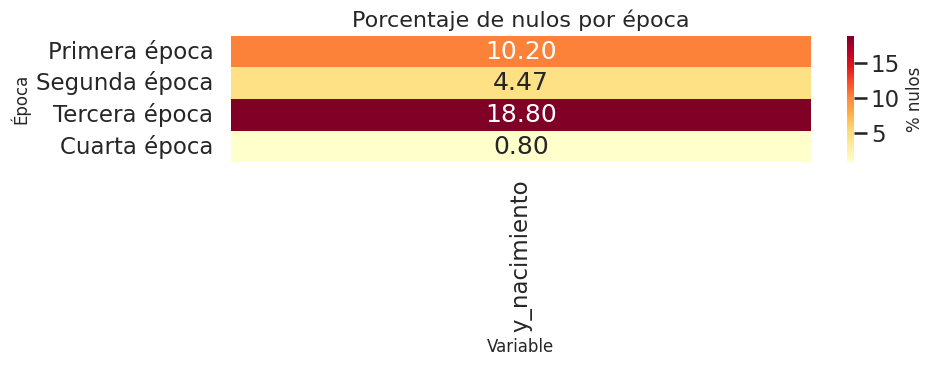

In [4]:
# ============================================================
# CÁLCULO DE PORCENTAJE DE NULOS POR ÉPOCA
# ============================================================
# Este bloque calcula, para cada época legislativa, qué porcentaje
# de valores faltantes (NaN) tiene la variable "y_nacimiento".

missing_by_era = (
    # Agrupa el DataFrame "plot_df" por la columna "era_label".
    # Cada grupo representa una época.
    plot_df.groupby("era_label")[["y_nacimiento"]]

    # Para cada grupo, calcula el porcentaje de valores nulos.
    # g.isna() devuelve True/False según si cada valor es nulo.
    # mean() sobre booleanos calcula la proporción de True.
    # Multiplicar por 100 convierte esa proporción en porcentaje.
    .apply(lambda g: g.isna().mean() * 100)

    # Renombra explícitamente el nombre del índice como "era_label".
    # Esto ayuda a que la estructura sea más clara al resetear índice.
    .rename_axis(index="era_label")

    # Convierte el índice nuevamente en una columna normal.
    # El resultado final es un DataFrame plano.
    .reset_index()
)

# Muestra la tabla resultante redondeando a 2 decimales.
# Sirve para inspeccionar numéricamente el porcentaje de nulos por época.
display(missing_by_era.round(2))


# ============================================================
# PREPARACIÓN DE DATOS PARA EL HEATMAP
# ============================================================
# Convierte la columna "era_label" en índice para que aparezca
# como eje Y del mapa de calor.
heat = missing_by_era.set_index("era_label")

# Crea la figura y el eje donde se dibujará el heatmap.
# figsize=(10, 4) define un gráfico ancho y relativamente bajo.
fig, ax = plt.subplots(figsize=(10, 4))

# Dibuja un mapa de calor con seaborn:
# - heat: tabla de datos a visualizar
# - annot=True: escribe el valor numérico dentro de cada celda
# - fmt=".2f": muestra los números con 2 decimales
# - cmap="YlOrRd": paleta de colores amarillo-naranja-rojo
# - cbar_kws: personaliza la barra lateral de color
# - ax=ax: dibuja sobre el eje creado antes
sns.heatmap(
    heat,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    cbar_kws={"label": "% nulos"},
    ax=ax
)

# Título principal del gráfico.
ax.set_title("Porcentaje de nulos por época")

# Etiqueta del eje X.
ax.set_xlabel("Variable")

# Etiqueta del eje Y.
ax.set_ylabel("Época")

# Rota las etiquetas del eje X en 90 grados para que no se encimen.
ax.tick_params(axis="x", labelrotation=90)

# Ajusta automáticamente los espacios del gráfico para evitar recortes.
plt.tight_layout()

# Muestra el gráfico final en pantalla.
plt.show()

# 3. Cumplimiento normativo y  requerimientos de interpretabilidad del modelo

sdfasdfasdfsdf

# 4. Alcance del analisis

# 5. Fuera del alcance del analisis

# 6. Analisis exploratorio de datos (EDA)

In [5]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)


CLEAN_DIR = Path('/home/miso/Projects/diputrax/data/database/clean/')

parquet_files = sorted(CLEAN_DIR.glob('*.parquet'))
if not parquet_files:
    raise FileNotFoundError(f'No parquet files in {CLEAN_DIR}')

latest = parquet_files[-1]
print(f'Parquet files found : {[f.name for f in parquet_files]}')
print(f'Using               : {latest.name}')

print(f'Loading: {latest.name}')
print(f'Size   : {latest.stat().st_size / 1_048_576:.2f} MB')

df = pd.read_parquet(latest)
print(f'Shape: {df.shape}')
df.head(3)

Parquet files found : ['diputados_20260421_205712.parquet']
Using               : diputados_20260421_205712.parquet
Loading: diputados_20260421_205712.parquet
Size   : 0.32 MB
Shape: (5000, 78)


,diputado_id,referencia,legislatura_nombre,legislatura_num,partido_nombre,nombre,partido,suplente_referencia,en_licencia,y_nacimiento,edad_al_tomar_cargo,grado_estudios_ord,mayoria_relativa,tiene_suplente,area_formacion,fue_diputado_local,fue_diputado_federal,fue_senador,n_cargos_legislativos_prev,entidad_codigo,distrito_circ,n_comisiones,n_comisiones_especiales,n_presidencias,n_secretarias,...,nivel_liderazgo_juvenil,tiene_posgrado,tiene_doctorado,estudios_en_extranjero,univ_publica,univ_privada,univ_extranjera,acad_unam,acad_itesm,acad_itam,acad_ibero,acad_udg,acad_ipn,acad_uam,acad_anahuac,acad_uanl,acad_uv,n_trayectoria_legislativa,n_trayectoria_politica,n_trayectoria_empresarial,n_investigacion_docencia,n_organos_gobierno,source_file,partido_mayoria,es_partido_mayoria
0,1c230671710f,569096,LIX,59,Partido Revolucionario Institucional,Abel Echeverría Pineda,PRI,2178850,False,1954.00,49.00,0,1,1,Otra,0,0,0,0,GRO,1 (Coyuca de Catalán),6,3,0,0,...,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,6,0,0,0,LIX_20260421_203103.csv,PRI,1
1,f2e201f17d25,569639,LIX,59,Partido Revolucionario Institucional,Juan Manuel Vega Rayet,PRI,2178954,False,1959.00,44.00,0,1,1,Otra,0,0,0,0,PUE,14 (Izúcar de Matamoros),3,0,0,0,...,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,11,6,0,0,LIX_20260421_203103.csv,PRI,1
2,f6992bc28127,570142,LIX,59,Partido Revolucionario Institucional,Homero Díaz Rodríguez,PRI,1605914,False,1959.00,44.00,0,0,1,Otra,0,0,0,0,DESCONOCIDO,NaN,2,0,0,1,...,2,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,8,4,0,0,LIX_20260421_203103.csv,PRI,1


In [6]:
roman_map = {
    57: 'LVII', 58: 'LVIII', 59: 'LIX', 60: 'LX', 61: 'LXI',
    62: 'LXII', 63: 'LXIII', 64: 'LXIV', 65: 'LXV', 66: 'LXVI'
}
plot_df = df.copy()
plot_df['legislatura_roman'] = plot_df['legislatura_num'].map(roman_map)


## 6.1 Calidad de datos

In [7]:
report = pd.DataFrame({
    'dtype': df.dtypes,
    'non_nulls': df.notnull().sum(),
    'nulls': df.isnull().sum(),
    'null_pct': df.isnull().mean() * 100,
    'unique': df.nunique()
}).sort_values('null_pct', ascending=False)
report


,dtype,non_nulls,nulls,null_pct,unique
edad_al_tomar_cargo,float64,4490,510,10.20,62
y_nacimiento,float64,4494,506,10.12,79
distrito_circ,str,4789,211,4.22,485
legislatura_nombre,str,5000,0,0.00,10
diputado_id,str,5000,0,0.00,4375
...,...,...,...,...,...
n_investigacion_docencia,int64,5000,0,0.00,10
n_organos_gobierno,int64,5000,0,0.00,8
source_file,str,5000,0,0.00,10
partido_mayoria,str,5000,0,0.00,3


,variable,nulos,pct
10,edad_al_tomar_cargo,510,10.20
9,y_nacimiento,506,10.12
20,distrito_circ,211,4.22


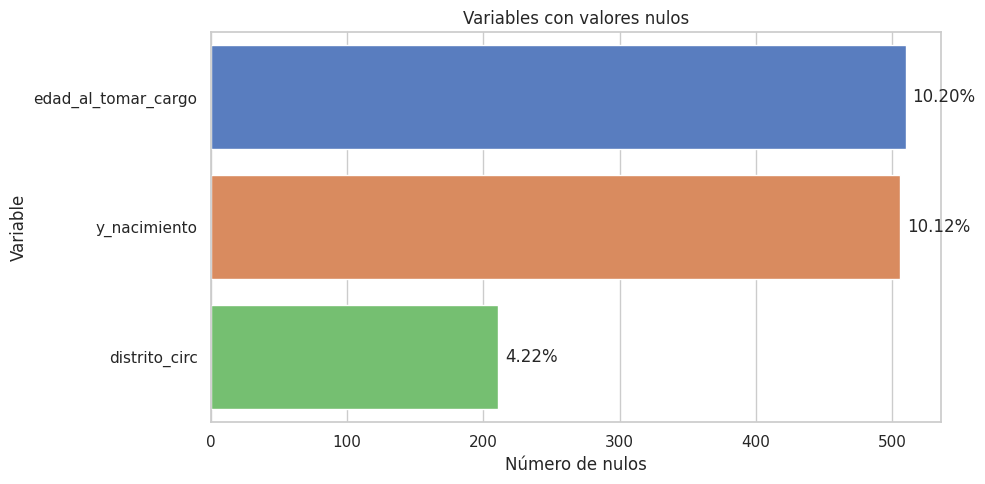

In [8]:
missing = (
    df.isna()
    .sum()
    .rename('nulos')
    .reset_index()
    .rename(columns={'index': 'variable'})
)
missing['pct'] = 100 * missing['nulos'] / len(df)
missing = missing[missing['nulos'] > 0].sort_values('nulos', ascending=False)

display(missing)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=missing, x='nulos', y='variable', hue='variable',
            dodge=False, ax=ax, legend=False)
ax.set_title('Variables con valores nulos')
ax.set_xlabel('Número de nulos')
ax.set_ylabel('Variable')
for i, row in missing.reset_index(drop=True).iterrows():
    ax.text(row['nulos'] + 5, i, f"{row['pct']:.2f}%", va='center')
plt.tight_layout()
plt.show()


## 6.2 Distribución legislativa

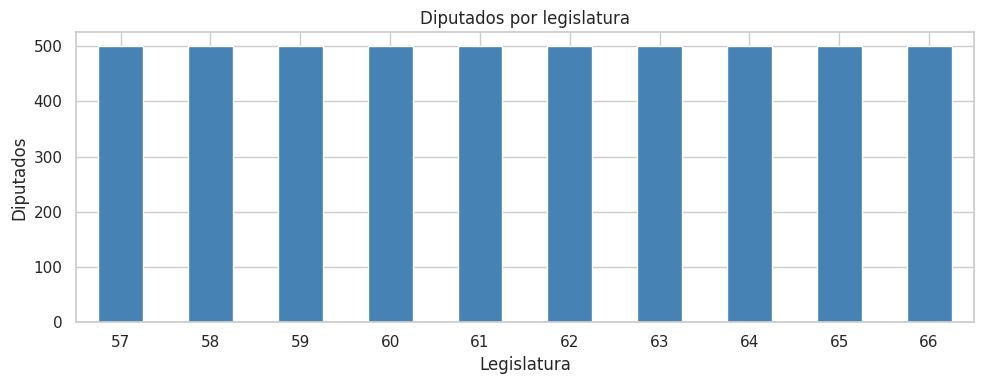

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
counts = df.groupby('legislatura_num').size()
counts.plot.bar(ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Legislatura')
ax.set_ylabel('Diputados')
ax.set_title('Diputados por legislatura')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


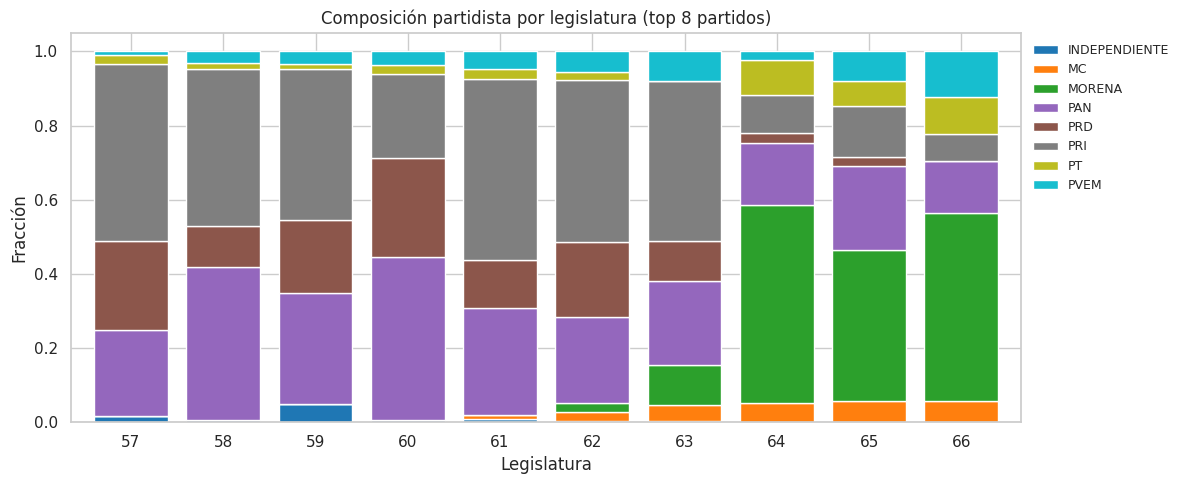

In [10]:
top8 = df['partido'].value_counts().head(8).index.tolist()
piv = (
    df[df['partido'].isin(top8)]
    .groupby(['legislatura_num', 'partido'])
    .size()
    .unstack(fill_value=0)
)
piv_pct = piv.div(piv.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
piv_pct.plot.bar(stacked=True, ax=ax, colormap='tab10',
                 edgecolor='white', width=0.8)
ax.set_title('Composición partidista por legislatura (top 8 partidos)')
ax.set_xlabel('Legislatura')
ax.set_ylabel('Fracción')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


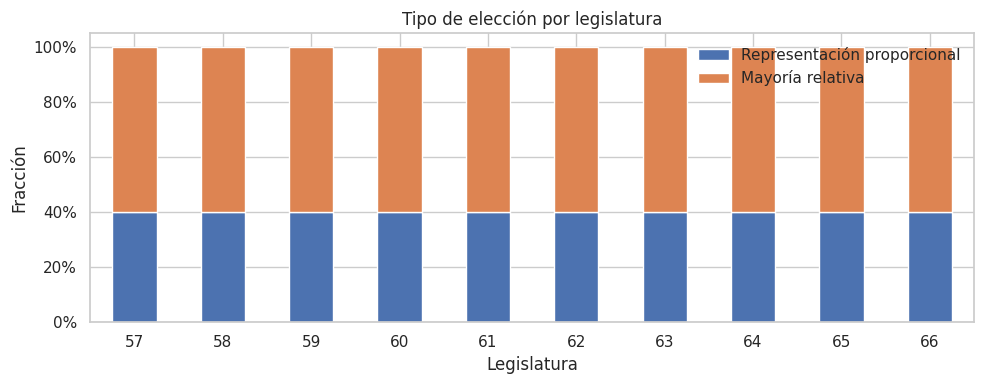

In [11]:
if 'mayoria_relativa' in df.columns:
    mr = df.groupby(['legislatura_num', 'mayoria_relativa']).size().unstack(fill_value=0)
    mr.columns = ['Representación proporcional', 'Mayoría relativa']
    mr_pct = mr.div(mr.sum(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(10, 4))
    mr_pct.plot.bar(stacked=True, ax=ax,
                    color=['#4C72B0', '#DD8452'], edgecolor='white')
    ax.set_title('Tipo de elección por legislatura')
    ax.set_xlabel('Legislatura')
    ax.set_ylabel('Fracción')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.legend(loc='upper right')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


## 6.3 Perfil demográfico

,edad_al_tomar_cargo
count,4490.00
mean,46.20
std,10.44
min,21.00
25%,39.00
50%,46.00
75%,53.00
max,85.00


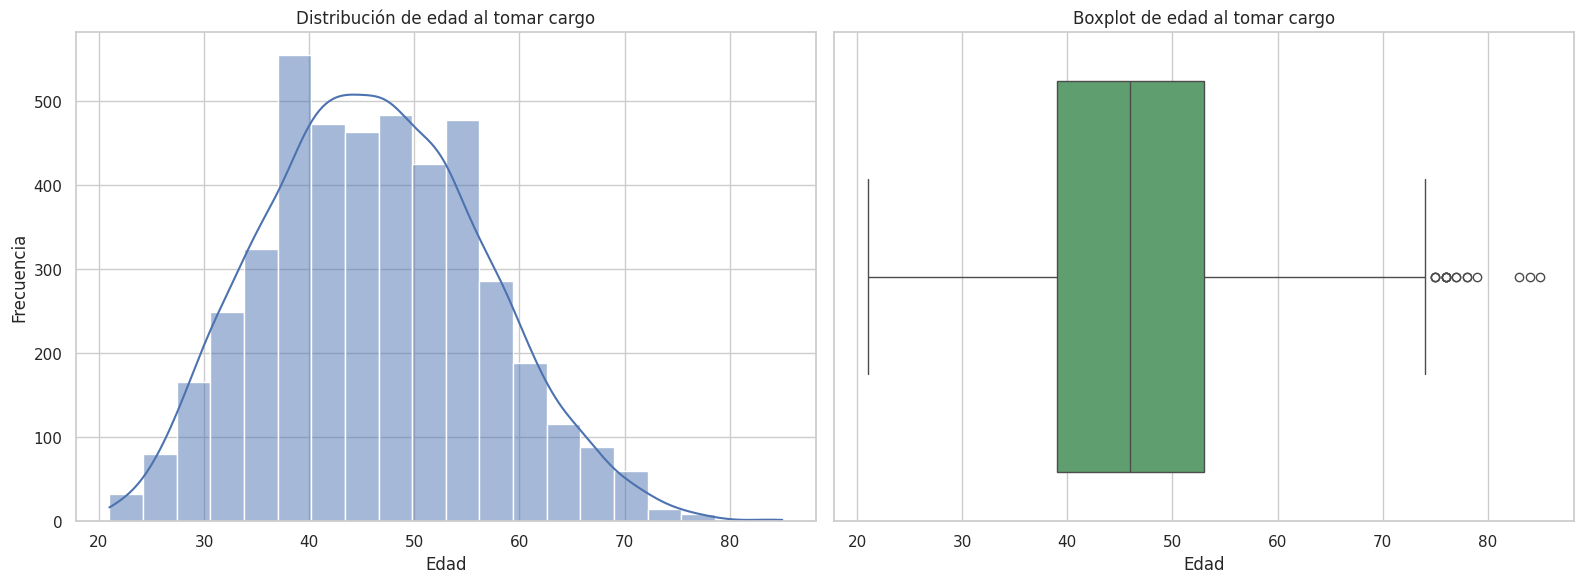

In [12]:
age_series = df['edad_al_tomar_cargo'].dropna()
display(age_series.describe().to_frame(name='edad_al_tomar_cargo'))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(age_series, bins=20, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribución de edad al tomar cargo')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(x=age_series, ax=axes[1], color='#55A868')
axes[1].set_title('Boxplot de edad al tomar cargo')
axes[1].set_xlabel('Edad')

plt.tight_layout()
plt.show()


,legislatura_num,legislatura_roman,edad_al_tomar_cargo
0,57,LVII,45.83
1,58,LVIII,44.22
2,59,LIX,44.58
3,60,LX,44.88
4,61,LXI,46.02
5,62,LXII,46.42
6,63,LXIII,46.01
7,64,LXIV,48.29
8,65,LXV,47.66
9,66,LXVI,48.37


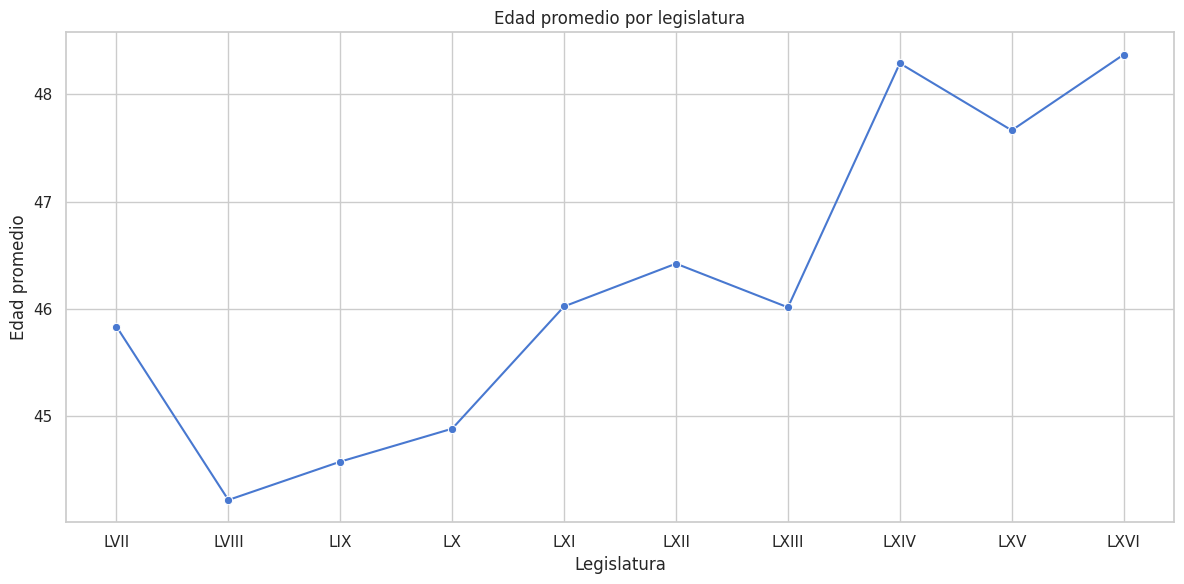

In [13]:
avg_age_leg = (
    plot_df.groupby(['legislatura_num', 'legislatura_roman'])['edad_al_tomar_cargo']
    .mean()
    .reset_index()
    .sort_values('legislatura_num')
)

display(avg_age_leg)

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=avg_age_leg, x='legislatura_roman', y='edad_al_tomar_cargo',
             marker='o', ax=ax)
ax.set_title('Edad promedio por legislatura')
ax.set_xlabel('Legislatura')
ax.set_ylabel('Edad promedio')
plt.tight_layout()
plt.show()


## 6.4 Perfil educativo

,grado_estudios_ord,n,etiqueta,pct
0,0,1839,Sin dato,36.78
1,1,62,Primaria,1.24
2,2,128,Secundaria,2.56
3,4,108,Preparatoria,2.16
4,5,324,Lic. incompleta,6.48
5,6,2335,Licenciatura,46.70
6,7,1,Especialidad,0.02
7,9,203,Doctorado,4.06


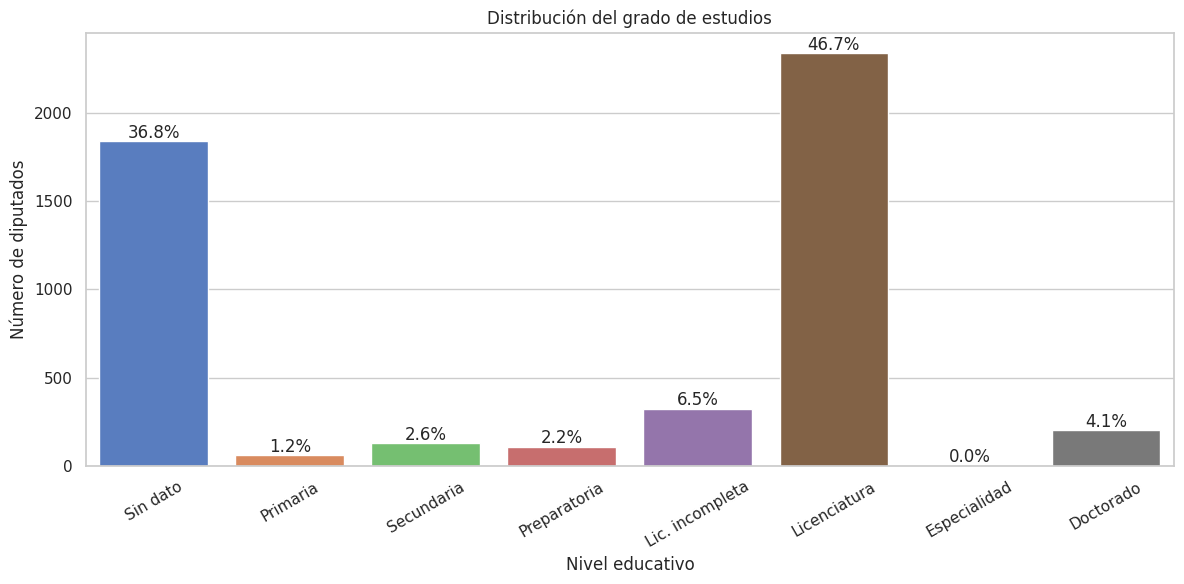

In [14]:
grade_labels = {
    0: 'Sin dato', 1: 'Primaria', 2: 'Secundaria',
    4: 'Preparatoria', 5: 'Lic. incompleta',
    6: 'Licenciatura', 7: 'Especialidad', 9: 'Doctorado',
}

grade_dist = (
    df['grado_estudios_ord']
    .fillna(-1)
    .astype(int)
    .value_counts()
    .sort_index()
    .rename_axis('grado_estudios_ord')
    .reset_index(name='n')
)
grade_dist['etiqueta'] = grade_dist['grado_estudios_ord'].map(grade_labels).fillna('Otro')
grade_dist['pct'] = 100 * grade_dist['n'] / len(df)

display(grade_dist)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=grade_dist, x='etiqueta', y='n', hue='etiqueta',
            dodge=False, ax=ax, legend=False)
ax.set_title('Distribución del grado de estudios')
ax.set_xlabel('Nivel educativo')
ax.set_ylabel('Número de diputados')
ax.tick_params(axis='x', rotation=30)
for i, row in grade_dist.reset_index(drop=True).iterrows():
    ax.text(i, row['n'] + 20, f"{row['pct']:.1f}%", ha='center')
plt.tight_layout()
plt.show()


,partido,promedio,n
6,PANAL,4.25,40
13,PT,4.09,189
4,MORENA,3.99,768
3,MC,3.98,120
14,PVEM,3.64,255
11,PRI,3.59,1564
5,PAN,3.55,1298
10,PRD,3.44,634
2,INDEPENDIENTE,2.11,47


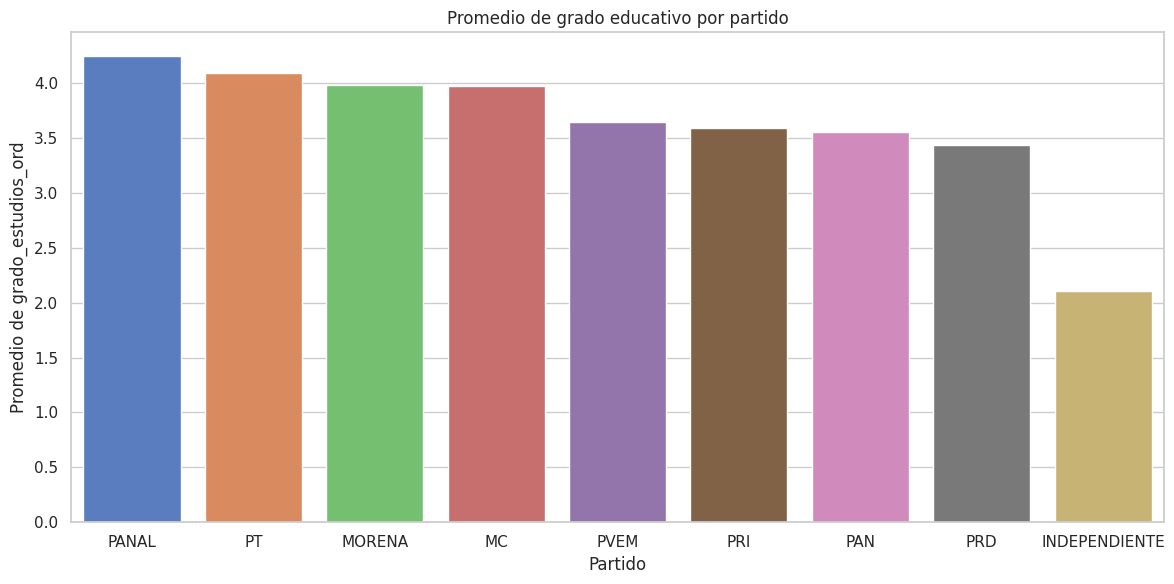

In [15]:
edu_by_party = (
    df.groupby('partido')['grado_estudios_ord']
    .agg(promedio='mean', n='size')
    .reset_index()
    .sort_values('promedio', ascending=False)
)
edu_by_party = edu_by_party[edu_by_party['n'] >= 40]

display(edu_by_party)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=edu_by_party, x='partido', y='promedio', hue='partido',
            dodge=False, ax=ax, legend=False)
ax.set_title('Promedio de grado educativo por partido')
ax.set_xlabel('Partido')
ax.set_ylabel('Promedio de grado_estudios_ord')
plt.tight_layout()
plt.show()


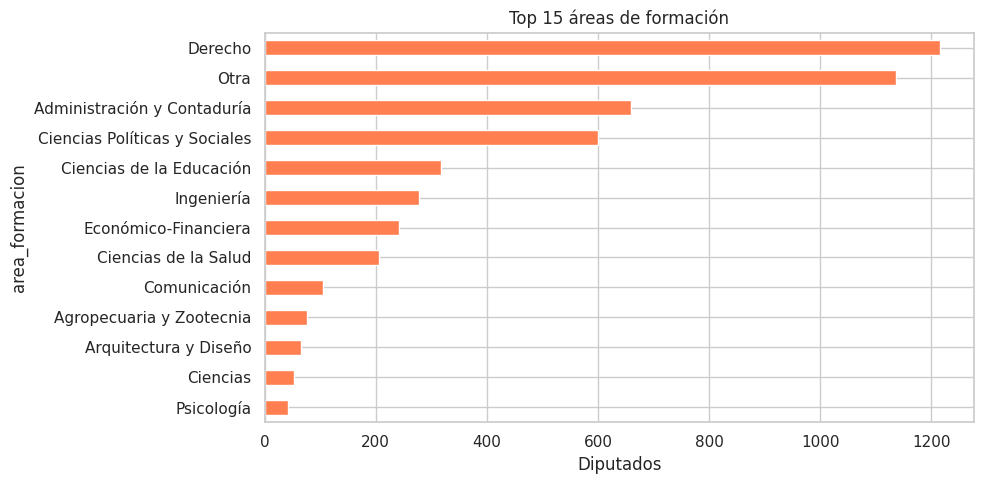

In [16]:
if 'area_formacion' in df.columns:
    af = df['area_formacion'].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(10, 5))
    af.plot.barh(ax=ax, color='coral', edgecolor='white')
    ax.invert_yaxis()
    ax.set_title('Top 15 áreas de formación')
    ax.set_xlabel('Diputados')
    plt.tight_layout()
    plt.show()


,tipo,n,pct
0,Pública,2191,43.82
1,Privada,1116,22.32
2,Extranjera,406,8.12
3,Sin universidad identificada,2090,41.80


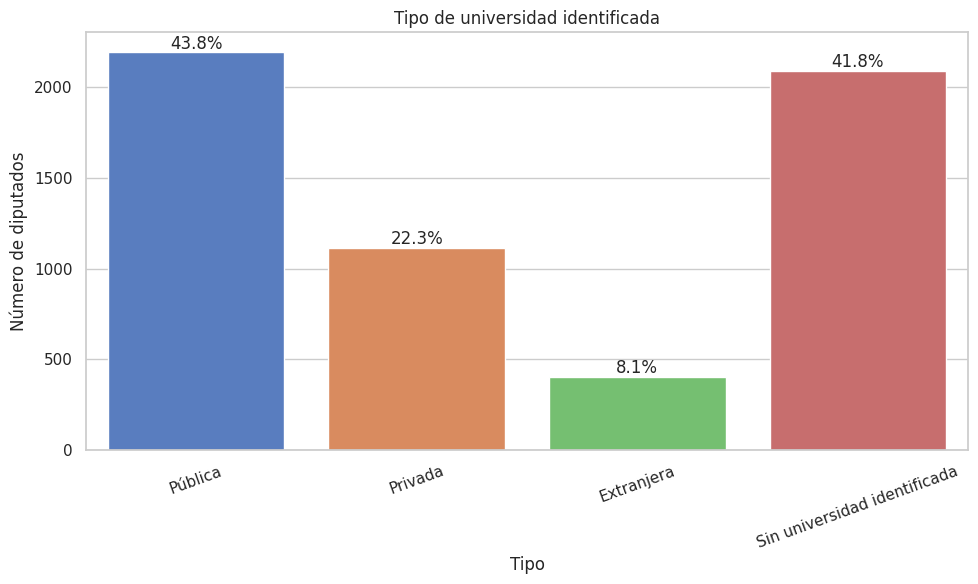

In [17]:
university_type = pd.DataFrame({
    'tipo': ['Pública', 'Privada', 'Extranjera', 'Sin universidad identificada'],
    'n': [
        int(df['univ_publica'].sum()),
        int(df['univ_privada'].sum()),
        int(df['univ_extranjera'].sum()),
        int((1 - df[['univ_publica', 'univ_privada', 'univ_extranjera']].max(axis=1)).sum()),
    ],
})
university_type['pct'] = 100 * university_type['n'] / len(df)

display(university_type)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=university_type, x='tipo', y='n', hue='tipo',
            dodge=False, ax=ax, legend=False)
ax.set_title('Tipo de universidad identificada')
ax.set_xlabel('Tipo')
ax.set_ylabel('Número de diputados')
ax.tick_params(axis='x', rotation=20)
for i, row in university_type.reset_index(drop=True).iterrows():
    ax.text(i, row['n'] + 20, f"{row['pct']:.1f}%", ha='center')
plt.tight_layout()
plt.show()


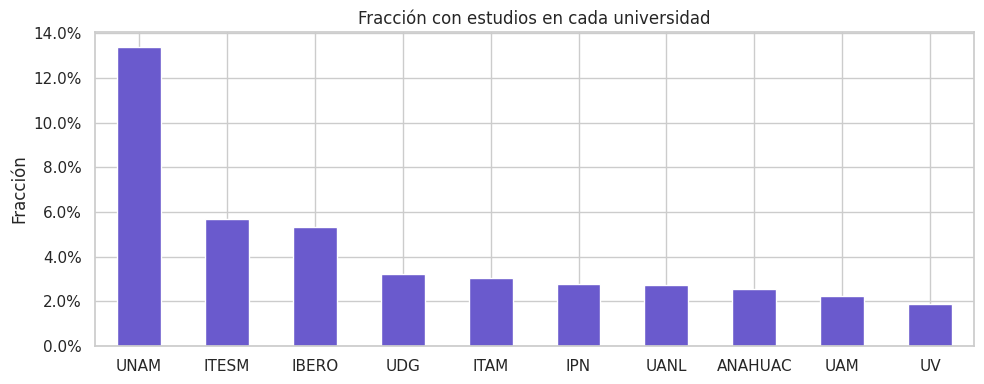

In [18]:
acad_cols = [c for c in df.columns if c.startswith('acad_')]
if acad_cols:
    acad_pct = df[acad_cols].mean().sort_values(ascending=False)
    acad_pct.index = acad_pct.index.str.replace('acad_', '', regex=False).str.upper()

    fig, ax = plt.subplots(figsize=(10, 4))
    acad_pct.plot.bar(ax=ax, color='slateblue', edgecolor='white')
    ax.set_title('Fracción con estudios en cada universidad')
    ax.set_ylabel('Fracción')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


## 6.5 Experiencia previa

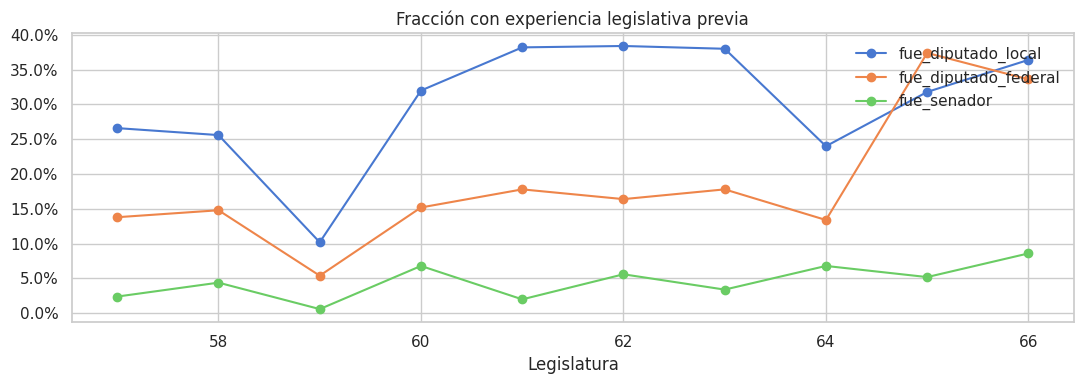

In [19]:
exp_cols = ['fue_diputado_local', 'fue_diputado_federal', 'fue_senador']
exp_cols = [c for c in exp_cols if c in df.columns]

if exp_cols:
    exp_by_leg = df.groupby('legislatura_num')[exp_cols].mean()

    fig, ax = plt.subplots(figsize=(11, 4))
    exp_by_leg.plot(ax=ax, marker='o')
    ax.set_title('Fracción con experiencia legislativa previa')
    ax.set_xlabel('Legislatura')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


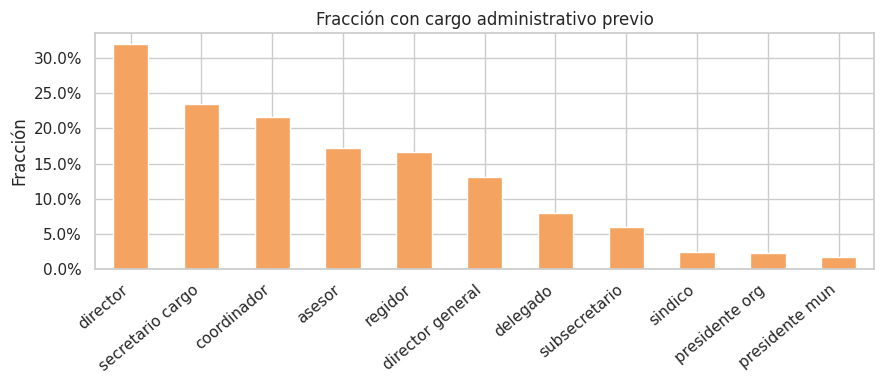

In [20]:
admin_cols = [
    'fue_presidente_mun', 'fue_presidente_org', 'fue_director_general',
    'fue_secretario_cargo', 'fue_subsecretario', 'fue_director',
    'fue_coordinador', 'fue_delegado', 'fue_asesor', 'fue_regidor', 'fue_sindico',
]
admin_cols = [c for c in admin_cols if c in df.columns]

admin_pct = df[admin_cols].mean().sort_values(ascending=False)
admin_pct.index = admin_pct.index.str.replace('fue_', '', regex=False).str.replace('_', ' ')

fig, ax = plt.subplots(figsize=(9, 4))
admin_pct.plot.bar(ax=ax, color='sandybrown', edgecolor='white')
ax.set_title('Fracción con cargo administrativo previo')
ax.set_ylabel('Fracción')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()


## 6.6 Trayectorias

,legislatura_num,legislatura_roman,n_trayectoria_admin,n_trayectoria_politica,n_trayectoria_legislativa,n_trayectoria_empresarial
0,57,LVII,2.78,6.99,0.62,1.40
1,58,LVIII,2.63,6.75,0.68,1.65
2,59,LIX,3.47,8.40,0.73,1.65
3,60,LX,3.14,6.59,0.75,2.13
4,61,LXI,4.00,7.59,0.85,1.90
5,62,LXII,3.42,6.05,0.80,1.68
6,63,LXIII,3.70,5.87,0.86,1.58
7,64,LXIV,2.62,4.31,0.62,1.54
8,65,LXV,2.85,4.18,0.97,1.40
9,66,LXVI,3.06,4.48,1.15,1.39


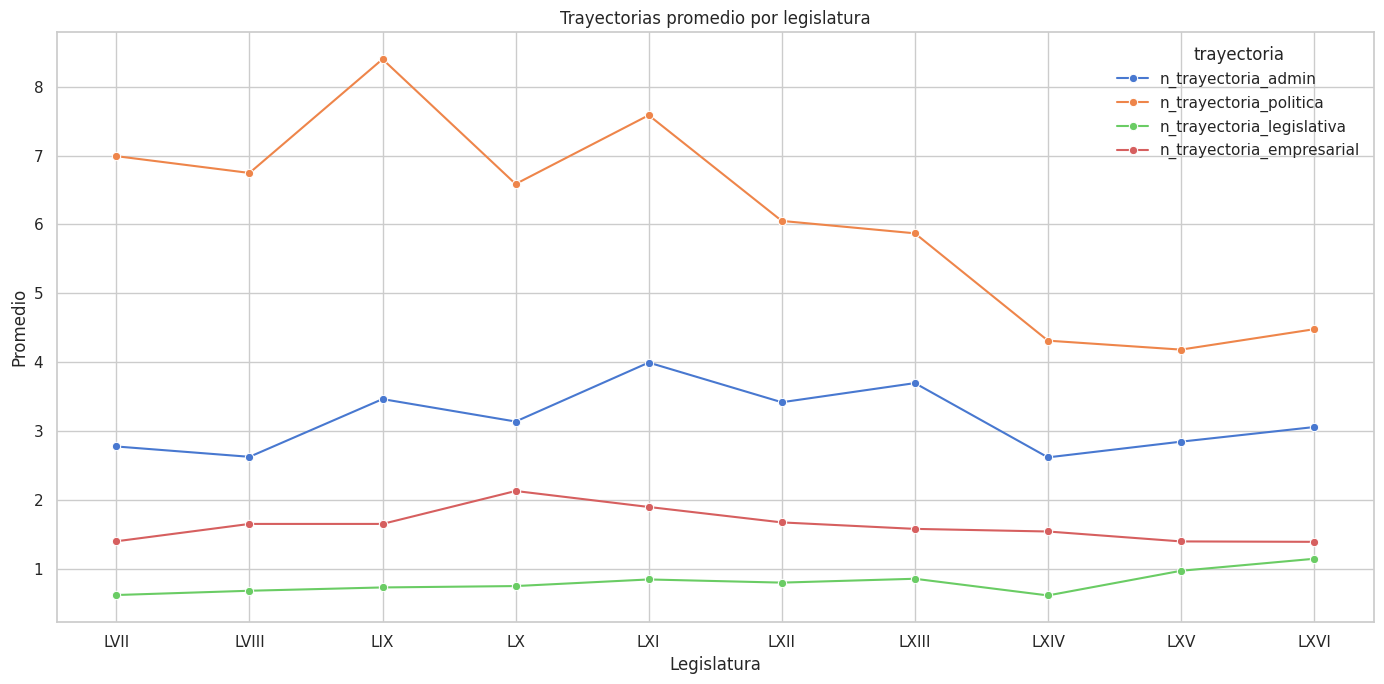

In [21]:
trajectory_by_leg = (
    plot_df.groupby(['legislatura_num', 'legislatura_roman'])[
        ['n_trayectoria_admin', 'n_trayectoria_politica',
         'n_trayectoria_legislativa', 'n_trayectoria_empresarial']
    ]
    .mean()
    .reset_index()
    .sort_values('legislatura_num')
)

display(trajectory_by_leg)

traj_long = trajectory_by_leg.melt(
    id_vars=['legislatura_num', 'legislatura_roman'],
    value_vars=['n_trayectoria_admin', 'n_trayectoria_politica',
                'n_trayectoria_legislativa', 'n_trayectoria_empresarial'],
    var_name='trayectoria',
    value_name='promedio',
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.lineplot(data=traj_long, x='legislatura_roman', y='promedio',
             hue='trayectoria', marker='o', ax=ax)
ax.set_title('Trayectorias promedio por legislatura')
ax.set_xlabel('Legislatura')
ax.set_ylabel('Promedio')
plt.tight_layout()
plt.show()


## 6.7 Comisiones

,partido,n_comisiones_nodales,n_comisiones_tematicas,n_comisiones_lastre,n_presidencias,total_comisiones_tipo
15,SIN PARTIDO,1.35,1.88,0.76,0.12,4.00
4,MORENA,0.88,2.19,0.69,0.14,3.76
14,PVEM,0.90,2.09,0.58,0.21,3.57
9,PES,0.62,2.00,0.74,0.29,3.35
13,PT,0.84,1.89,0.53,0.16,3.27
3,MC,0.72,1.87,0.59,0.17,3.18
6,PANAL,0.65,2.05,0.38,0.23,3.07
1,CONVERGENCIA,0.96,1.52,0.57,0.26,3.04


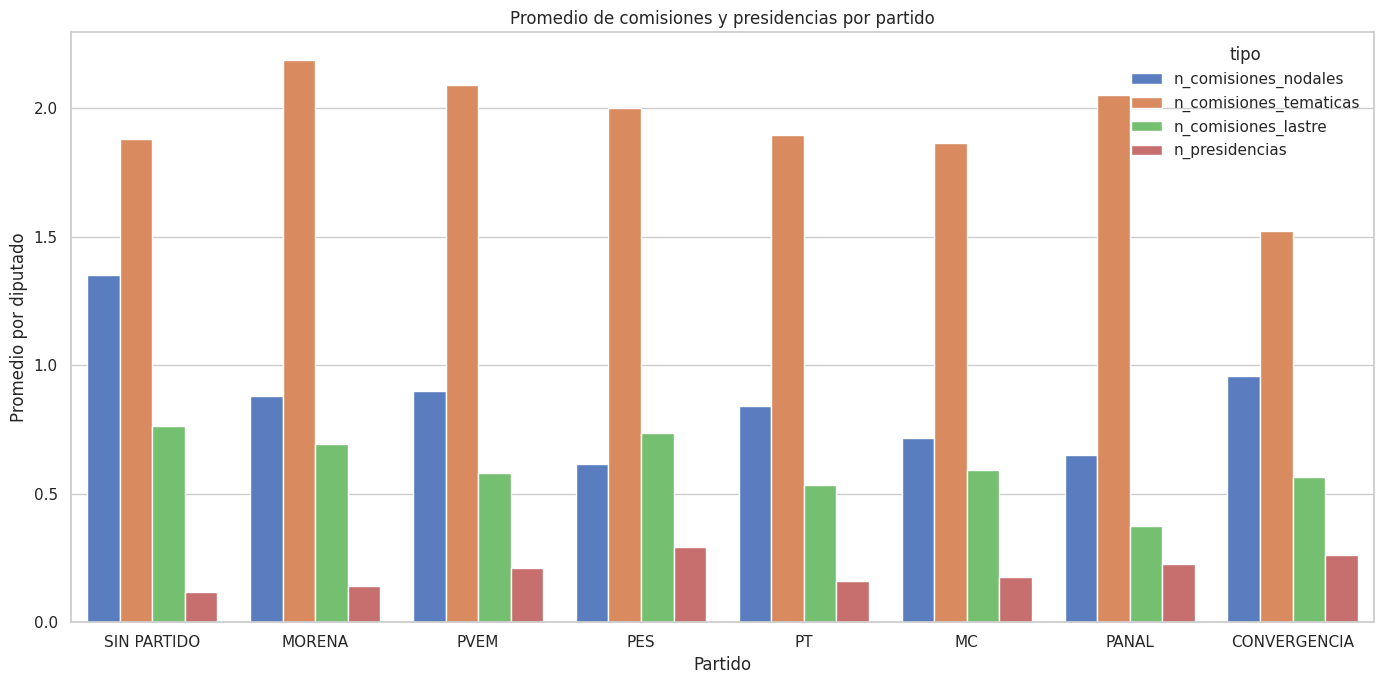

In [22]:
by_party = (
    df.groupby('partido')[[
        'n_comisiones_nodales', 'n_comisiones_tematicas',
        'n_comisiones_lastre', 'n_presidencias'
    ]]
    .mean()
    .reset_index()
)
by_party['total_comisiones_tipo'] = (
    by_party['n_comisiones_nodales']
    + by_party['n_comisiones_tematicas']
    + by_party['n_comisiones_lastre']
)
by_party = by_party.sort_values('total_comisiones_tipo', ascending=False).head(8)

display(by_party)

party_long = by_party.melt(
    id_vars='partido',
    value_vars=['n_comisiones_nodales', 'n_comisiones_tematicas',
                'n_comisiones_lastre', 'n_presidencias'],
    var_name='tipo',
    value_name='promedio',
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(data=party_long, x='partido', y='promedio', hue='tipo', ax=ax)
ax.set_title('Promedio de comisiones y presidencias por partido')
ax.set_xlabel('Partido')
ax.set_ylabel('Promedio por diputado')
plt.tight_layout()
plt.show()


## 6.8 Relaciones multivariadas

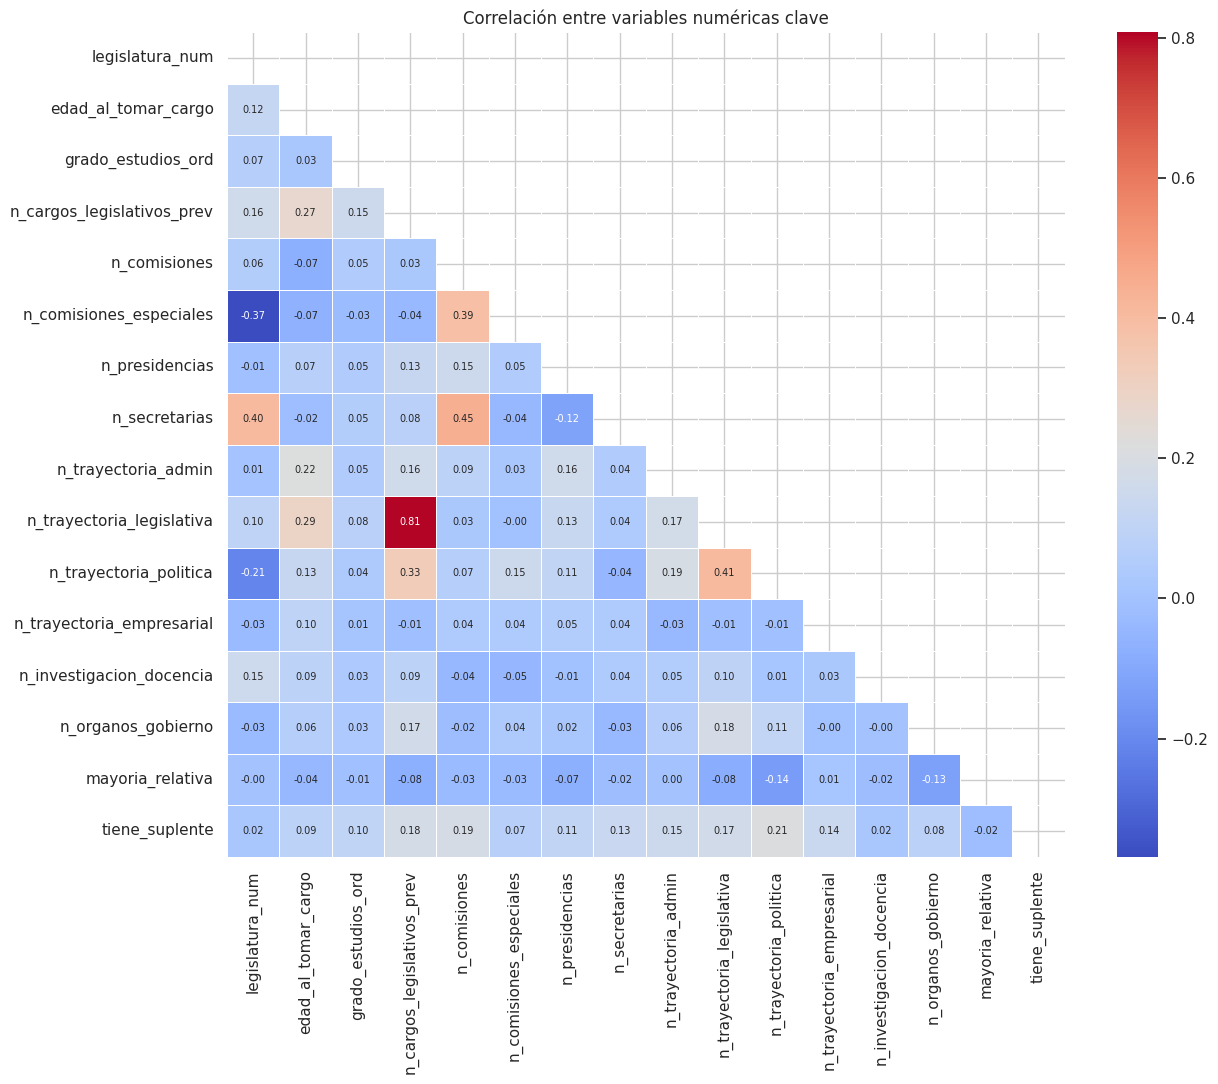

In [23]:
key_numeric = [
    'legislatura_num', 'edad_al_tomar_cargo', 'grado_estudios_ord',
    'n_cargos_legislativos_prev', 'n_comisiones', 'n_comisiones_especiales',
    'n_presidencias', 'n_secretarias',
    'n_trayectoria_admin', 'n_trayectoria_legislativa',
    'n_trayectoria_politica', 'n_trayectoria_empresarial',
    'n_investigacion_docencia', 'n_organos_gobierno',
    'mayoria_relativa', 'tiene_suplente',
]
key_numeric = [c for c in key_numeric if c in df.columns]

corr = df[key_numeric].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.5, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Correlación entre variables numéricas clave')
plt.tight_layout()
plt.show()


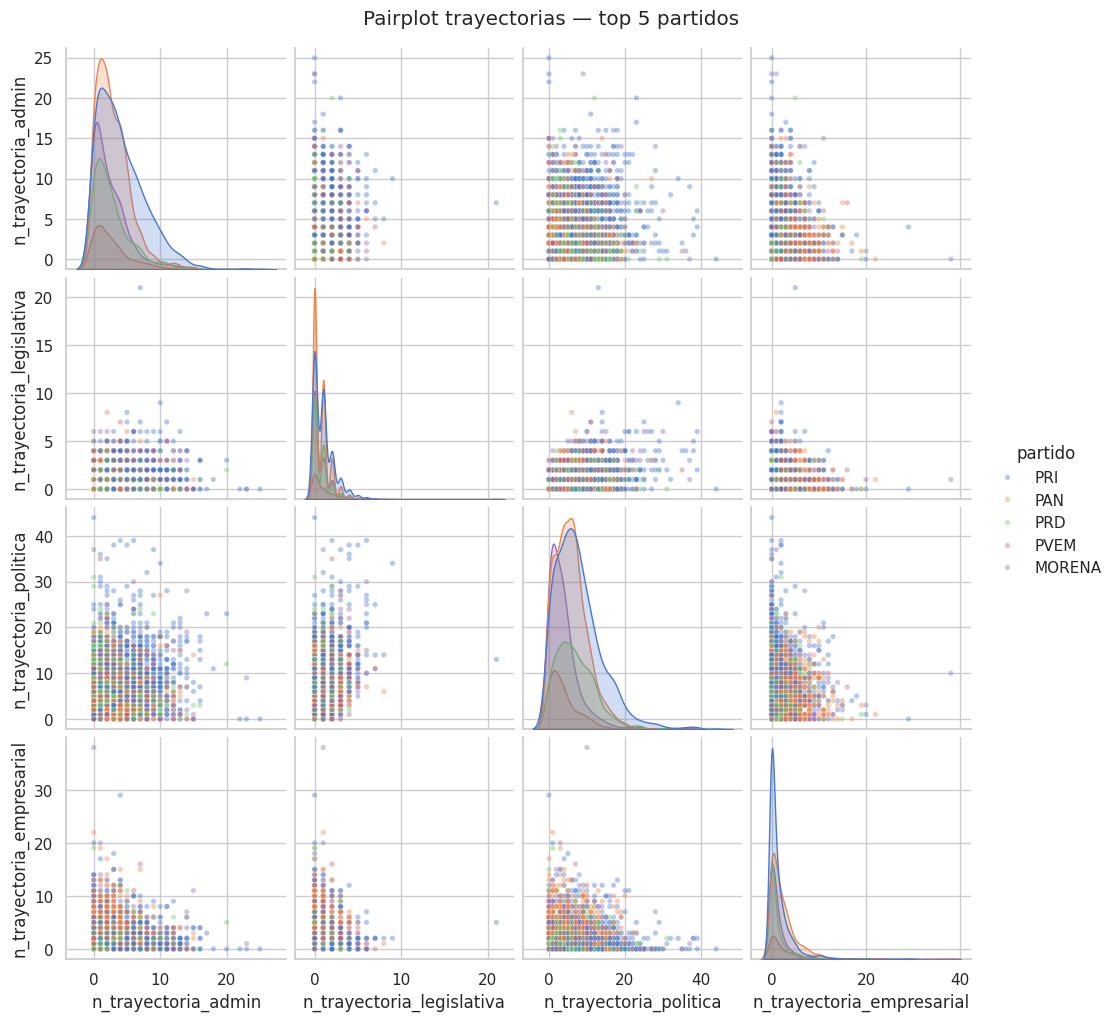

In [24]:
traj_cols = [
    'n_trayectoria_admin', 'n_trayectoria_legislativa',
    'n_trayectoria_politica', 'n_trayectoria_empresarial',
]
traj_cols = [c for c in traj_cols if c in df.columns]

if traj_cols:
    sample = df[traj_cols + ['partido']].dropna()
    top5 = sample['partido'].value_counts().head(5).index
    sample = sample[sample['partido'].isin(top5)]

    g = sns.pairplot(sample, hue='partido', vars=traj_cols,
                     plot_kws={'alpha': 0.4, 's': 15})
    g.figure.suptitle('Pairplot trayectorias — top 5 partidos', y=1.02)
    plt.show()
